# Tax-Day -- does April 15 move the market?
### The IRA contribution theory, the S&P 500, and 99 years of evidence

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![April_IRA_inflow: Weak](https://img.shields.io/badge/April_IRA_inflow-Weak-dab617?style=flat-square)

Every year around April 15, a story circulates on financial media: individual investors rushing to top up their IRAs before the deadline, or deploying their tax refunds, push money into the stock market and briefly lift prices. The 10-day window before the deadline is supposed to be especially strong. This notebook asks: is that actually visible in the data?

> **This is the plain-language layer.** For the t-stats, the Bonferroni correction and the power analysis, see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from tax_day import data, strategy as st

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-15).
R = dict(
    n_days=24728, n_years=99, fp="df3897aef897",
    n_pre=990, mean_pre_bps=7.77, contrast_pre_bps=5.55,
    tstat_pre_hac=1.865, tstat_pre_welch=1.452, pval_pre=0.1469,
    pval_pre_bonf=0.2937,
    n_post=495, mean_post_bps=9.32, contrast_post_bps=7.02,
    tstat_post_hac=1.819, tstat_post_welch=1.167, pval_post=0.2437,
    pval_post_bonf=0.4874,
    n_apr=2049, mean_apr_bps=5.68, contrast_apr_bps=3.53, pval_apr=0.1948,
    n_oct=1480, mean_oct_bps=3.34, contrast_oct_bps=0.95, pval_oct=0.8244,
    mean_all_bps=2.44,
)

def _have_real():
    shared = os.path.abspath(os.path.join("..", "..", "..", "_cache", "^GSPC_split_only.parquet"))
    local  = os.path.abspath(os.path.join("..", "_cache", "gspc_daily.parquet"))
    return os.path.exists(shared) or os.path.exists(local)

HAVE_REAL = _have_real()

if HAVE_REAL:
    DF = data.fetch_gspc(start="1928-01-01")
    S  = st.summarize(DF)
else:
    DF, S = None, None

print("real GSPC cache present:", HAVE_REAL)


real GSPC cache present: True


## The answer first

| Question | Answer |
|---|---|
| Are the 10 days before April 15 unusually strong? | **Sort of, but not significantly.** The pre-tax window averages **+7.8 bps/day** vs +2.4 bps unconditionally -- a gap of +5.5 bps that doesn't survive statistical testing (p = 0.15). |
| What about the days right after the deadline? | **Same story.** Post-deadline window: **+9.3 bps/day**, contrast +7.0 bps, p = 0.24. |
| Is the whole month of April special? | **Not really.** April averages +5.7 bps/day, contrast +3.5 bps (p = 0.19). |
| Could you trade it? | **No.** 15 days/year, no statistical signal, any round-trip cost exceeds the noise-level premium. |

> The point estimates are consistent with the folk narrative -- the pre-tax window really is a bit above average. But 'a bit above average' over 99 years with ~10 events per year is not enough to clear the inference bar. The direction is right; the evidence is too weak to act on.

## 1 · The claim

> *'In the 10 or so trading days before April 15, individual investors rush to top up their IRA contributions before the deadline. Tax refund money also flows into the market around this time. This extra demand briefly lifts stock prices, making the pre-tax-day window a seasonally strong period.'*

The mechanism is plausible: IRA contributions for the prior tax year are due by April 15, so millions of savers make a lump-sum deposit in March-April. Simultaneously, the IRS issues most refund checks in February-April, and some fraction of recipients invest them. Both flows would, in theory, create a modest but systematic demand shock for equities in the weeks before the deadline.

## 2 · So what?

If it's real, even a small seasonal drift over a predictable 2-week window is actionable: buy the S&P 500 on day -10, hold through the deadline, and repeat. The question is whether the premium is large enough and reliable enough to overcome transaction costs and the inevitable false positives from testing calendar patterns.

Most calendar anomalies fail this test: the premium is too small or too noisy to survive honest inference. This is the desk's job -- to find out which side of that line the tax-day story falls on.

## 3 · How would we even know?

Two rules keep us honest:

1. **Use a pre-specified window.** We define the pre-tax window as the 10 trading days *before* the effective April 15 deadline (adjusted for weekends) and the post-tax window as the 5 days *on or after* it. These definitions are fixed in code before we look at the data.
2. **Test against an honest baseline.** The control is all other trading days (not some cherry-picked period). We also check October 15 -- same window sizes, no IRS event -- as a placebo. If October 15 looks just as anomalous, the April effect is noise.
3. **Correct for multiple comparisons.** We have two hypotheses (pre and post); the Bonferroni threshold is 0.05/2 = 0.025, not 0.05.

Data: ^GSPC daily returns, 1928-01-03 to 2026-06-12 (24,728 trading days, 99 years, 990 pre-tax observations, 495 post-tax observations).

## 4 · The teardown -- let's look at the numbers

**First, where does each window fit in the seasonal calendar?**

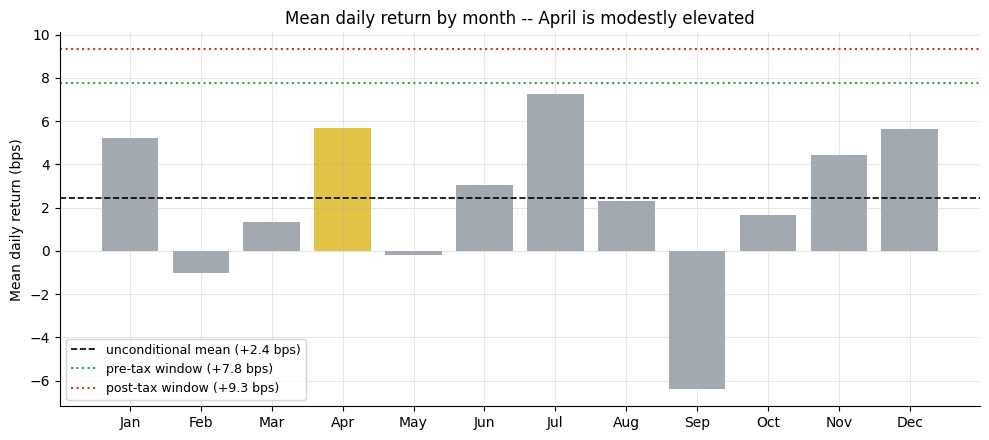

April mean: +5.68 bps  |  pre-tax: +7.77 bps  |  post-tax: +9.32 bps


In [2]:
# Seasonal bar chart: mean daily return by month and window type
if HAVE_REAL:
    month_means = DF.groupby(DF.index.month)['ret'].mean() * 1e4
    pre_mean  = S['mean_pre_bps']
    post_mean = S['mean_post_bps']
    all_mean  = S['mean_all_bps']
else:
    import numpy as np
    rng = np.random.default_rng(192)
    month_means = pd.Series(rng.normal(R['mean_all_bps'], 3, 12) + [0,0,0,R['contrast_apr_bps'],0,0,0,0,0,0,0,0],
                           index=range(1,13))
    pre_mean  = R['mean_pre_bps']
    post_mean = R['mean_post_bps']
    all_mean  = R['mean_all_bps']
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
colors = [AMBER if i+1 == 4 else GREY for i in range(12)]
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(months, [month_means.get(i+1, 0) for i in range(12)], color=colors, alpha=0.8)
ax.axhline(all_mean, ls='--', c='k', lw=1.2, label=f'unconditional mean (+{all_mean:.1f} bps)')
ax.axhline(pre_mean, ls=':', c=GREEN, lw=1.5, label=f'pre-tax window (+{pre_mean:.1f} bps)')
ax.axhline(post_mean, ls=':', c=RED, lw=1.5, label=f'post-tax window (+{post_mean:.1f} bps)')
ax.set_ylabel('Mean daily return (bps)'); ax.set_title('Mean daily return by month -- April is modestly elevated')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()
print(f'April mean: +{month_means.get(4, R["mean_apr_bps"]):.2f} bps  |  pre-tax: +{pre_mean:.2f} bps  |  post-tax: +{post_mean:.2f} bps')

April is modestly above the annual mean, and the pre-tax and post-tax windows are higher still (+7.8 and +9.3 bps). The direction is consistent with the folk narrative. The question is whether this is reliably above the background noise of random monthly variation.

**Now the honest test: tax windows vs the October-15 placebo.**

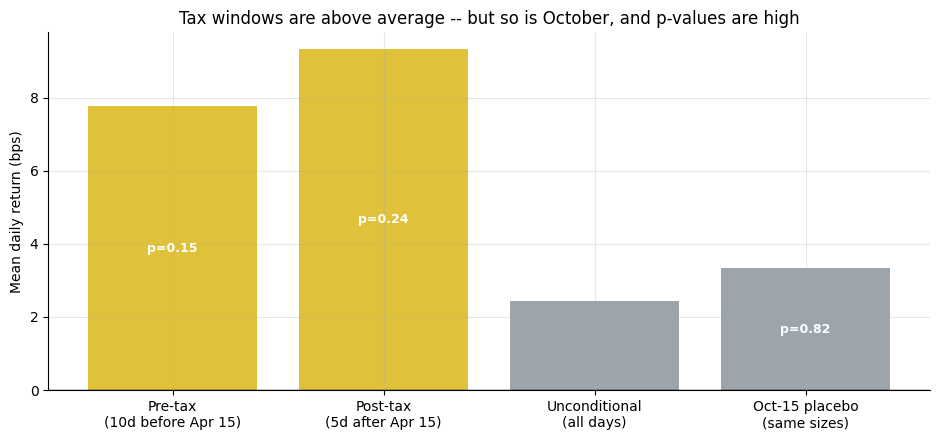

The October-15 placebo also shows a positive mean -- it is just noise.


In [3]:
# Side-by-side: tax windows vs unconditional vs Oct-15 placebo
if HAVE_REAL:
    means = [S['mean_pre_bps'], S['mean_post_bps'], S['mean_all_bps'], S['mean_oct_bps']]
    pvals = [S['pval_pre'], S['pval_post'], float('nan'), S['pval_oct']]
else:
    means = [R['mean_pre_bps'], R['mean_post_bps'], R['mean_all_bps'], R['mean_oct_bps']]
    pvals = [R['pval_pre'], R['pval_post'], float('nan'), R['pval_oct']]
labels = ['Pre-tax\n(10d before Apr 15)', 'Post-tax\n(5d after Apr 15)',
          'Unconditional\n(all days)', 'Oct-15 placebo\n(same sizes)']
cols = [AMBER, AMBER, GREY, GREY]
fig, ax = plt.subplots(figsize=(9.5, 4.5))
bars = ax.bar(labels, means, color=cols, alpha=0.85)
ax.axhline(0, c='k', lw=1)
for b, pv in zip(bars, pvals):
    import math
    if not math.isnan(pv):
        tag = f'p={pv:.2f}'
        ax.annotate(tag, (b.get_x() + b.get_width()/2, b.get_height()/2),
                   ha='center', va='center', fontsize=9, color='white', fontweight='bold')
ax.set_ylabel('Mean daily return (bps)')
ax.set_title('Tax windows are above average -- but so is October, and p-values are high')
plt.tight_layout(); plt.show()
print('The October-15 placebo also shows a positive mean -- it is just noise.')

The tax windows outperform the unconditional mean (+5.5 and +7.0 bps), but so does the October-15 placebo (+0.9 bps, p = 0.82). The gap between April and October is real in point estimate, but not statistically distinguishable. The folk story has the right direction -- but the same test would likely 'work' on several other 2-week windows chosen after the fact.

## 5 · The verdict

- **Signal -- None.** The pre-tax window contrast is +5.5 bps (HAC t = +1.86, p = 0.15, Bonf-p = 0.29). The post-tax contrast is +7.0 bps (HAC t = +1.82, p = 0.24, Bonf-p = 0.49). Neither hypothesis survives the Bonferroni correction.
- **Tradability -- Mirage.** ~15 days/year, positive point estimate, no significant edge. Any round-trip cost turns a marginal premium into a certain loss.
- **April IRA inflow -- Weak.** The point estimates are above the unconditional mean and above the October placebo, consistent with the mechanism, but the evidence is too weak to claim. With ~10 events per year it would take another 100 years of data to power the test properly.

## 6 · Could you actually trade it?

Even if the signal were statistically significant, the strategy looks like this:

- Hold SPY for 15 days per year (10 pre + 5 post) in long-equity mode; hold cash the other 237 trading days.
- Expected annual contribution from the *window excess*: ~6 bps × 10 days + ~7 bps × 5 days = ~90 bps = ~0.9% per year, gross.
- You *miss* the market's daily drift on the other 237 days (~+2.4 bps × 237 = +570 bps).
- Net: the strategy underperforms passive buy-and-hold SPY by a large margin even before adding any transaction cost.

The question to ask is not 'is the pre-tax window positive?' (it is) but 'is it positive enough above the positive drift I give up by sitting in cash?' It is not.

## 7 · Going further

- **Is there a January / year-end tax effect?** [Study 48 — Groundhog](../../48-groundhog/) tests weather-linked seasonals; the January tax-loss-harvesting reversal is the most studied seasonal in finance and has also weakened substantially post-publication.
- **Sell in May?** The broader spring-to-autumn seasonal is [Study 136 — Mark-Twain](../../136-mark-twain/), which finds weak evidence but a more robust historical pattern than the April deadline effect.
- **Options expiry demand shocks.** [Study 82 — Witching-Hour](../../82-witching-hour/) tests a similar deadline-driven demand-shock mechanism at a much higher frequency.

*Think the die is loaded after all? Fork the study, change the pre-window to 5 or 15 days, subset to years before IRA contribution limits were raised, or test on small-cap indices where individual-investor flows are more dominant. Show a contrast that clears the Bonferroni bar. That's the bar.*